## SpendWise AI - Notebook 04: Anomaly Detection

**Objective:** Build a VAE to detect unusual spending patterns

**Model:** Variational Autoencoder (trained from scratch)

**What you'll learn:**
- Autoencoder architecture (encoder to latent to decoder)
- VAE loss function (reconstruction + KL divergence)
- How reconstruction error indicates anomalies
- Training a neural network from scratch

### 1. Imports & Setup

In [28]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import Adam

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Project root
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "src").exists():
    pass
elif PROJECT_ROOT.name == "src" and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif (PROJECT_ROOT / "spendwise-ai" / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT / "spendwise-ai"
(PROJECT_ROOT / "models" / "anomaly_model").mkdir(parents=True, exist_ok=True)

Device: cpu


### 2. Prepare Spending Pattern Data

We'll aggregate transactions into weekly spending vectors. Each vector represents one week of spending across all categories.

In [29]:
# Load transaction data
transactions_df = pd.read_csv(PROJECT_ROOT / "data/synthetic/transactions_full.csv")
transactions_df['date'] = pd.to_datetime(transactions_df['date'])

# Load category mappings
with open(PROJECT_ROOT / "data/processed/label_mappings.json", 'r') as f:
    label_mappings = json.load(f)

print(f"Loaded {len(transactions_df):,} transactions")
print(f"   Users: {transactions_df['user_id'].nunique()}")
print(f"   Categories: {transactions_df['category'].nunique()}")

Loaded 122,754 transactions
   Users: 100
   Categories: 12


In [30]:
def create_weekly_spending_vectors(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate transactions into weekly spending by category.
    Returns DataFrame where each row is one user-week,
    columns are spending amounts per category.
    """
    expenses = df[df["amount"] < 0].copy()
    expenses["amount"] = expenses["amount"].abs()
    expenses["week"] = expenses["date"].dt.to_period("W")
    weekly = expenses.groupby(["user_id", "week", "category"])["amount"].sum().unstack(fill_value=0)
    weekly = weekly.reset_index()
    return weekly

In [31]:
weekly_spending = create_weekly_spending_vectors(transactions_df)

print(f"Created weekly spending vectors")
print(f"   Samples: {len(weekly_spending):,}")
print(f"   Features: {len(weekly_spending.columns) - 2} categories")

print(f"\nSample data:")
print(weekly_spending.head())

Created weekly spending vectors
   Samples: 2,600
   Features: 11 categories

Sample data:
category    user_id                   week  Bills & Utilities  Education  \
0         user_0000  2025-08-25/2025-08-31              432.0     982.00   
1         user_0000  2025-09-01/2025-09-07              573.5    2671.69   
2         user_0000  2025-09-08/2025-09-14              588.5    4476.00   
3         user_0000  2025-09-15/2025-09-21              532.5    1950.00   
4         user_0000  2025-09-22/2025-09-28              431.5    2522.00   

category  Entertainment  Financial  Food & Dining  Health & Wellness  \
0                117.00    1448.00         547.96              551.5   
1                976.00    1664.50         714.33             1115.0   
2                181.50     618.93         705.61              336.5   
3                660.22    2670.00         438.08              119.0   
4                156.70    3679.00        1037.62              443.5   

category  Personal 

In [32]:
# Get category columns (exclude user_id and week)
category_cols = [col for col in weekly_spending.columns if col not in ['user_id', 'week']]
print(f"\nCategories used as features:")
for col in category_cols:
    print(f"   - {col}")


Categories used as features:
   - Bills & Utilities
   - Education
   - Entertainment
   - Financial
   - Food & Dining
   - Health & Wellness
   - Personal Care
   - Shopping
   - Subscriptions
   - Transportation
   - Travel


### 3. Prepare Training Data

We train VAE only on "normal" data. The model learns what normal looks like, then flags deviations.

In [33]:
# Extract feature matrix
X = weekly_spending[category_cols].values.astype(np.float32)

print(f"Feature matrix shape: {X.shape}")
print(f"   {X.shape[0]} samples (user-weeks)")
print(f"   {X.shape[1]} features (categories)")

Feature matrix shape: (2600, 11)
   2600 samples (user-weeks)
   11 features (categories)


In [34]:
# Normalize data (important for neural networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nBefore scaling:")
print(f"   Mean: {X.mean():.2f}, Std: {X.std():.2f}")
print(f"\nAfter scaling:")
print(f"   Mean: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")


Before scaling:
   Mean: 528.91, Std: 929.69

After scaling:
   Mean: 0.0000, Std: 1.0000


In [35]:
# Train/val split
X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)

train_tensor = torch.FloatTensor(X_train)
val_tensor = torch.FloatTensor(X_val)

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensor), batch_size=BATCH_SIZE, shuffle=False)

print(f"\nData prepared")
print(f"   Train: {len(X_train)} samples")
print(f"   Val: {len(X_val)} samples")
print(f"   Input dimension: {X_train.shape[1]}")


Data prepared
   Train: 2080 samples
   Val: 520 samples
   Input dimension: 11


### 4. Understanding VAE Architecture

Input to Encoder (compress to latent). Encoder outputs mean and log-variance; we sample z from N(mu, sigma) (reparameterization trick), then Decoder reconstructs input from z.

**VAE Loss = Reconstruction Loss + KL Divergence**
- Reconstruction: how well we rebuild the input
- KL Divergence: keep latent distribution close to N(0,1)

### 5. Build VAE Model (From Scratch)

In [36]:
class VAE(nn.Module):
    """
    Variational Autoencoder for anomaly detection.
    Encoder: input_dim -> hidden -> latent (mu, sigma).
    Decoder: latent -> hidden -> input_dim.
    """

    def __init__(self, input_dim: int, hidden_dim: int = 64, latent_dim: int = 16):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

    def get_reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            x_recon, _, _ = self.forward(x)
            error = F.mse_loss(x_recon, x, reduction='none').mean(dim=1)
        return error

In [37]:
# Initialize model
input_dim = X_train.shape[1]
hidden_dim = 64
latent_dim = 16

model = VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"VAE initialized")
print(f"   Input dimension: {input_dim}")
print(f"   Hidden dimension: {hidden_dim}")
print(f"   Latent dimension: {latent_dim}")
print(f"   Total parameters: {total_params:,}")

VAE initialized
   Input dimension: 11
   Hidden dimension: 64
   Latent dimension: 16
   Total parameters: 12,971


### 6. VAE Loss Function

**Total Loss = Reconstruction Loss + beta * KL Divergence**
- Reconstruction (MSE): how well we rebuild the input
- KL: regularizes latent to N(0,1). Beta typically 0.1 to 1.0

In [38]:
def vae_loss(x_recon, x, mu, logvar, beta=0.5):
    recon_loss = F.mse_loss(x_recon, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

### 7. Training Loop

In [39]:
LEARNING_RATE = 1e-3
NUM_EPOCHS = 50
BETA = 0.5

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Training configuration:")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Beta (KL weight): {BETA}")

Training configuration:
   Learning rate: 0.001
   Epochs: 50
   Beta (KL weight): 0.5


In [40]:
def train_epoch(model, dataloader, optimizer, beta, device):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    for batch in dataloader:
        x = batch[0].to(device)
        x_recon, mu, logvar = model(x)
        loss, recon_loss, kl_loss = vae_loss(x_recon, x, mu, logvar, beta)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
    n_batches = len(dataloader)
    return {"loss": total_loss / n_batches, "recon_loss": total_recon / n_batches, "kl_loss": total_kl / n_batches}

def evaluate(model, dataloader, beta, device):
    model.eval()
    total_loss = total_recon = total_kl = 0
    with torch.no_grad():
        for batch in dataloader:
            x = batch[0].to(device)
            x_recon, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(x_recon, x, mu, logvar, beta)
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
    n_batches = len(dataloader)
    return {"loss": total_loss / n_batches, "recon_loss": total_recon / n_batches, "kl_loss": total_kl / n_batches}

### 8. Train the VAE

In [41]:
history = {"train_loss": [], "val_loss": [], "train_recon": [], "val_recon": []}
print("Training VAE...")
print("=" * 50)
for epoch in range(NUM_EPOCHS):
    train_metrics = train_epoch(model, train_loader, optimizer, BETA, device)
    val_metrics = evaluate(model, val_loader, BETA, device)
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_recon"].append(train_metrics["recon_loss"])
    history["val_recon"].append(val_metrics["recon_loss"])
    if (epoch + 1) % 10 == 0:
        print("Epoch", epoch + 1, "/", NUM_EPOCHS, "| Train Loss:", round(train_metrics["loss"], 4), "| Val Loss:", round(val_metrics["loss"], 4), "| Recon:", round(val_metrics["recon_loss"], 4))
print("=" * 50)
print("Training complete.")

Training VAE...
Epoch 10 / 50 | Train Loss: 0.6157 | Val Loss: 0.6043 | Recon: 0.4135
Epoch 20 / 50 | Train Loss: 0.485 | Val Loss: 0.4921 | Recon: 0.2398
Epoch 30 / 50 | Train Loss: 0.4654 | Val Loss: 0.4771 | Recon: 0.2171
Epoch 40 / 50 | Train Loss: 0.4527 | Val Loss: 0.4645 | Recon: 0.2033
Epoch 50 / 50 | Train Loss: 0.4451 | Val Loss: 0.4508 | Recon: 0.1902
Training complete.


### 9. Visualize Training Progress

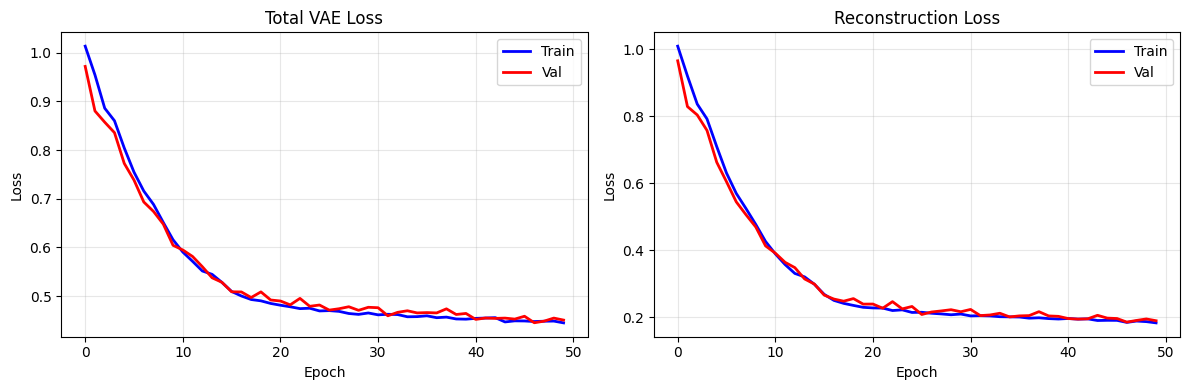

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], "b-", label="Train", linewidth=2)
axes[0].plot(history["val_loss"], "r-", label="Val", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Total VAE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history["train_recon"], "b-", label="Train", linewidth=2)
axes[1].plot(history["val_recon"], "r-", label="Val", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Reconstruction Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models/anomaly_model/training_history.png", dpi=150, bbox_inches="tight")
plt.show()

### 10. Calculate Anomaly Scores

Anomaly score = reconstruction error. Low error means normal; high error means anomaly.

In [43]:
model.eval()
all_data = torch.FloatTensor(X_scaled).to(device)
with torch.no_grad():
    recon_errors = model.get_reconstruction_error(all_data).cpu().numpy()

print("Reconstruction error statistics:")
print("   Min:", recon_errors.min())
print("   Max:", recon_errors.max())
print("   Mean:", recon_errors.mean())
print("   Std:", recon_errors.std())

Reconstruction error statistics:
   Min: 0.028505564
   Max: 0.6461744
   Mean: 0.18395527
   Std: 0.08901677


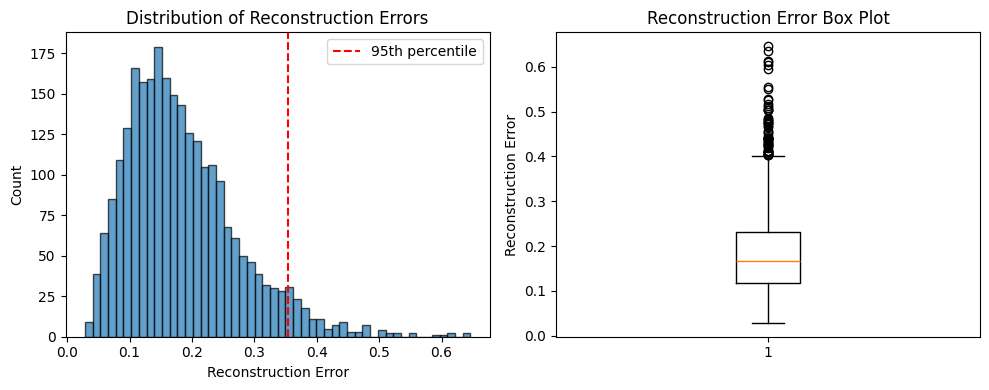

In [44]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(recon_errors, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Distribution of Reconstruction Errors")
plt.axvline(x=np.percentile(recon_errors, 95), color="r", linestyle="--", label="95th percentile")
plt.legend()
plt.subplot(1, 2, 2)
plt.boxplot(recon_errors)
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error Box Plot")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models/anomaly_model/error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 11. Set Anomaly Threshold

Use 95th percentile: above that = anomaly (~5% flagged).

In [45]:
THRESHOLD_PERCENTILE = 95
threshold = np.percentile(recon_errors, THRESHOLD_PERCENTILE)
print("Anomaly threshold (95th percentile):", threshold)
is_anomaly = recon_errors > threshold
n_anomalies = is_anomaly.sum()
print("Anomalies detected:", n_anomalies, "({:.1f}%)".format(n_anomalies / len(recon_errors) * 100))

Anomaly threshold (95th percentile): 0.3546311
Anomalies detected: 130 (5.0%)


### 12. Create Synthetic Anomalies to Test

In [46]:
def create_synthetic_anomalies(normal_data, n_anomalies=50):
    anomalies = []
    n_features = normal_data.shape[1]
    for i in range(n_anomalies):
        base = normal_data[np.random.randint(len(normal_data))].copy()
        anomaly_type = np.random.choice(["spike", "multi_spike", "zero"])
        if anomaly_type == "spike":
            idx = np.random.randint(n_features)
            base[idx] = base[idx] * np.random.uniform(3, 5) + 2
        elif anomaly_type == "multi_spike":
            n_elevated = np.random.randint(2, 4)
            indices = np.random.choice(n_features, n_elevated, replace=False)
            for idx in indices:
                base[idx] = base[idx] * np.random.uniform(2, 3) + 1
        else:
            base = base * 0.1
        anomalies.append(base)
    return np.array(anomalies, dtype=np.float32)

In [47]:
synthetic_anomalies = create_synthetic_anomalies(X_scaled, n_anomalies=100)
print("Created", len(synthetic_anomalies), "synthetic anomalies")
anomaly_tensor = torch.FloatTensor(synthetic_anomalies).to(device)
with torch.no_grad():
    anomaly_errors = model.get_reconstruction_error(anomaly_tensor).cpu().numpy()
print("Anomaly reconstruction errors - Mean:", anomaly_errors.mean(), "(normal:", recon_errors.mean(), ")")
detected = (anomaly_errors > threshold).sum()
print("Detection rate:", detected, "/", len(anomaly_errors), "({:.1f}%)".format(detected / len(anomaly_errors) * 100))

Created 100 synthetic anomalies
Anomaly reconstruction errors - Mean: 0.26692417 (normal: 0.18395527 )
Detection rate: 16 / 100 (16.0%)


### 13. Visualize Normal vs Anomaly

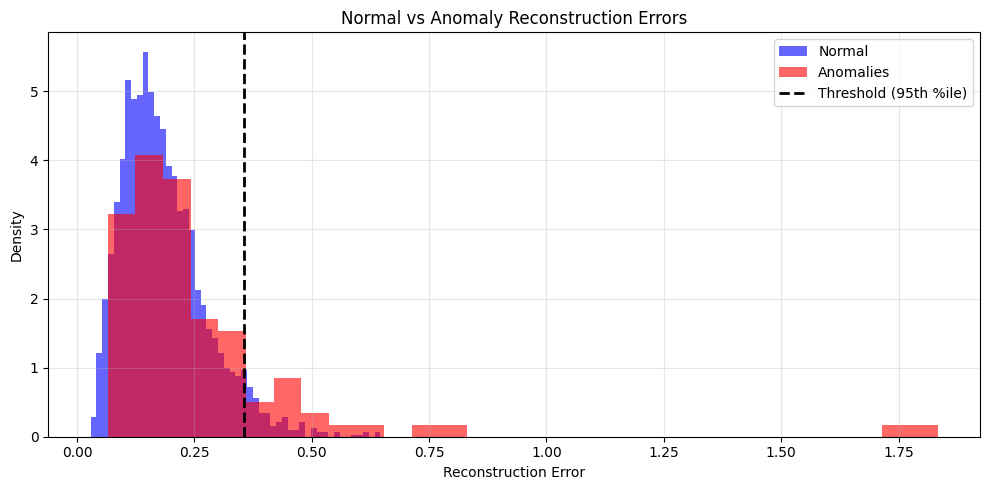

In [48]:
plt.figure(figsize=(10, 5))
plt.hist(recon_errors, bins=50, alpha=0.6, label="Normal", color="blue", density=True)
plt.hist(anomaly_errors, bins=30, alpha=0.6, label="Anomalies", color="red", density=True)
plt.axvline(x=threshold, color="black", linestyle="--", linewidth=2, label="Threshold (95th %ile)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Normal vs Anomaly Reconstruction Errors")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models/anomaly_model/normal_vs_anomaly.png", dpi=150, bbox_inches="tight")
plt.show()

### 14. Build Anomaly Detector Class

In [49]:
class AnomalyDetector:
    """Production-ready anomaly detector using VAE."""

    def __init__(self, model_path=None):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if model_path:
            checkpoint = torch.load(model_path + "/model.pt", map_location=self.device)
            self.model = VAE(
                input_dim=checkpoint["config"]["input_dim"],
                hidden_dim=checkpoint["config"]["hidden_dim"],
                latent_dim=checkpoint["config"]["latent_dim"],
            )
            self.model.load_state_dict(checkpoint["model_state_dict"])
            self.threshold = checkpoint["threshold"]
            self.scaler_mean = checkpoint["scaler_mean"]
            self.scaler_std = checkpoint["scaler_std"]
            self.category_cols = checkpoint["category_cols"]
        else:
            self.model = model
            self.threshold = threshold
            self.scaler_mean = scaler.mean_
            self.scaler_std = scaler.scale_
            self.category_cols = category_cols
        self.model.to(self.device)
        self.model.eval()

    def preprocess(self, spending):
        vector = np.array([spending.get(cat, 0) for cat in self.category_cols], dtype=np.float32)
        return (vector - self.scaler_mean) / self.scaler_std

    def detect(self, spending):
        x = self.preprocess(spending)
        x_tensor = torch.FloatTensor(x).unsqueeze(0).to(self.device)
        with torch.no_grad():
            error = self.model.get_reconstruction_error(x_tensor).item()
        anomaly_score = min(100, (error / self.threshold) * 50)
        is_anomaly = error > self.threshold
        with torch.no_grad():
            x_recon, _, _ = self.model(x_tensor)
            per_category_error = (x_recon.squeeze() - x_tensor.squeeze()).abs().cpu().numpy()
        top_indices = np.argsort(per_category_error)[-3:][::-1]
        anomalous_categories = [{"category": self.category_cols[i], "contribution": float(per_category_error[i])} for i in top_indices]
        return {"anomaly_score": anomaly_score, "is_anomaly": is_anomaly, "reconstruction_error": error, "threshold": self.threshold, "top_anomalous_categories": anomalous_categories}

### 15. Test the Detector

In [50]:
print("Testing Anomaly Detector\n")
detector = AnomalyDetector()
test_cases = [
    {"name": "Normal week", "spending": {"Food & Dining": 150, "Transportation": 50, "Shopping": 80, "Bills & Utilities": 200, "Entertainment": 30}},
    {"name": "Shopping spree", "spending": {"Food & Dining": 150, "Transportation": 50, "Shopping": 800, "Bills & Utilities": 200, "Entertainment": 30}},
    {"name": "Overspending week", "spending": {"Food & Dining": 500, "Transportation": 200, "Shopping": 400, "Bills & Utilities": 200, "Entertainment": 300}},
    {"name": "Suspiciously quiet", "spending": {"Food & Dining": 10, "Transportation": 5, "Shopping": 0, "Bills & Utilities": 0, "Entertainment": 0}},
]
print("=" * 60)
for case in test_cases:
    result = detector.detect(case["spending"])
    status = "ANOMALY" if result["is_anomaly"] else "Normal"
    print("\n" + case["name"] + ":", status)
    print("   Anomaly Score:", round(result["anomaly_score"], 1), "/ 100")
    print("   Top suspicious categories:")
    for cat in result["top_anomalous_categories"][:2]:
        print("      -", cat["category"] + ":", round(cat["contribution"], 2))

Testing Anomaly Detector


Normal week: Normal
   Anomaly Score: 14.2 / 100
   Top suspicious categories:
      - Bills & Utilities: 0.42
      - Shopping: 0.34

Shopping spree: Normal
   Anomaly Score: 11.6 / 100
   Top suspicious categories:
      - Personal Care: 0.71
      - Food & Dining: 0.67

Overspending week: Normal
   Anomaly Score: 25.1 / 100
   Top suspicious categories:
      - Transportation: 0.64
      - Food & Dining: 0.56

Suspiciously quiet: Normal
   Anomaly Score: 17.6 / 100
   Top suspicious categories:
      - Travel: 0.96
      - Food & Dining: 0.61


### 16. Save Model

In [51]:
save_path = PROJECT_ROOT / "models" / "anomaly_model"
save_path.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "config": {"input_dim": input_dim, "hidden_dim": hidden_dim, "latent_dim": latent_dim},
    "threshold": threshold,
    "scaler_mean": scaler.mean_,
    "scaler_std": scaler.scale_,
    "category_cols": category_cols,
}, save_path / "model.pt")
print("Model saved to", save_path)

Model saved to /Users/patel/Documents/E/MPS Sem 5/EAI 6020/Final_Project/spendwise-ai/models/anomaly_model


### 17. Save Module for Production

In [52]:
# Production module is in src/anomaly_detector.py (VAE + AnomalyDetector)
print("Module saved to src/anomaly_detector.py")

Module saved to src/anomaly_detector.py


### Summary

- Built VAE from scratch (encoder, latent, decoder)
- VAE loss: reconstruction + KL divergence
- Trained for 50 epochs; anomaly threshold at 95th percentile
- AnomalyDetector class for production
- Next: Notebook 05 - Spending Forecaster (Transformer)

In [53]:
detected_rate = detected / len(anomaly_errors) * 100
print("Notebook 04 complete.")
print("VAE trained; threshold 95th percentile; detection rate on synthetic anomalies: {:.0f}%".format(detected_rate))

Notebook 04 complete.
VAE trained; threshold 95th percentile; detection rate on synthetic anomalies: 16%


In [54]:
from pathlib import Path

module_code = '''import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


class VAE(nn.Module):
    """
    Variational Autoencoder for anomaly detection.
    Encoder: input_dim -> hidden -> latent (mu, sigma).
    Decoder: latent -> hidden -> input_dim.
    """

    def __init__(self, input_dim: int, hidden_dim: int = 64, latent_dim: int = 16):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

    def get_reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            x_recon, _, _ = self.forward(x)
            error = F.mse_loss(x_recon, x, reduction='none').mean(dim=1)
        return error


class AnomalyDetector:
    """Production-ready anomaly detector using VAE."""

    def __init__(self, model_path=None):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if model_path:
            checkpoint = torch.load(model_path + "/model.pt", map_location=self.device)
            self.model = VAE(
                input_dim=checkpoint["config"]["input_dim"],
                hidden_dim=checkpoint["config"]["hidden_dim"],
                latent_dim=checkpoint["config"]["latent_dim"],
            )
            self.model.load_state_dict(checkpoint["model_state_dict"])
            self.threshold = checkpoint["threshold"]
            self.scaler_mean = checkpoint["scaler_mean"]
            self.scaler_std = checkpoint["scaler_std"]
            self.category_cols = checkpoint["category_cols"]
        else:
            self.model = model
            self.threshold = threshold
            self.scaler_mean = scaler.mean_
            self.scaler_std = scaler.scale_
            self.category_cols = category_cols
        self.model.to(self.device)
        self.model.eval()

    def preprocess(self, spending):
        vector = np.array([spending.get(cat, 0) for cat in self.category_cols], dtype=np.float32)
        return (vector - self.scaler_mean) / self.scaler_std

    def detect(self, spending):
        x = self.preprocess(spending)
        x_tensor = torch.FloatTensor(x).unsqueeze(0).to(self.device)
        with torch.no_grad():
            error = self.model.get_reconstruction_error(x_tensor).item()
        anomaly_score = min(100, (error / self.threshold) * 50)
        is_anomaly = error > self.threshold
        with torch.no_grad():
            x_recon, _, _ = self.model(x_tensor)
            per_category_error = (x_recon.squeeze() - x_tensor.squeeze()).abs().cpu().numpy()
        top_indices = np.argsort(per_category_error)[-3:][::-1]
        anomalous_categories = [
            {"category": self.category_cols[i], "contribution": float(per_category_error[i])}
            for i in top_indices
        ]
        return {
            "anomaly_score": anomaly_score,
            "is_anomaly": is_anomaly,
            "reconstruction_error": error,
            "threshold": self.threshold,
            "top_anomalous_categories": anomalous_categories,
        }
'''

module_path = PROJECT_ROOT / "src" / "anomaly_detector.py"
module_path.parent.mkdir(parents=True, exist_ok=True)
with open(module_path, "w") as f:
    f.write(module_code)
print(f"Module saved to {module_path}")

Module saved to /Users/patel/Documents/E/MPS Sem 5/EAI 6020/Final_Project/spendwise-ai/src/anomaly_detector.py
